# AVIP 2026 Task 3: Stock Price Data Visualization

This notebook analyzes the downloaded Yahoo Finance data in `data/TCS.NS_daily.csv`. It does not create or modify source stock data. Re-running the analysis uses the actual CSV present in the project.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")

PROJECT_DIR = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "data" / "TCS.NS_daily.csv").is_file()
    ),
    None,
)
if PROJECT_DIR is None:
    raise FileNotFoundError(
        "Could not locate data/TCS.NS_daily.csv. Run this notebook from the project tree."
    )

DATA_PATH = PROJECT_DIR / "data" / "TCS.NS_daily.csv"
CHARTS_DIR = PROJECT_DIR / "charts"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Source dataset: {DATA_PATH}")

Source dataset: c:\Users\HP\Desktop\DS_3_Stock_Price_Visualization_byte\data\TCS.NS_daily.csv


In [2]:
raw_data = pd.read_csv(DATA_PATH)
required_columns = {"Date", "Close"}
missing_columns = required_columns.difference(raw_data.columns)
if missing_columns:
    raise ValueError(
        "The source CSV is missing required columns: "
        + ", ".join(sorted(missing_columns))
    )

# Clean a working copy only; never write changes to the downloaded source CSV.
working = raw_data.copy()
working["Date"] = pd.to_datetime(working["Date"], errors="coerce")
working["Close"] = pd.to_numeric(working["Close"], errors="coerce")
finite_close = np.isfinite(working["Close"].to_numpy(dtype=float, na_value=np.nan))
valid_rows = working["Date"].notna() & finite_close
excluded_rows = int((~valid_rows).sum())
data = working.loc[valid_rows, ["Date", "Close"]].copy()
data = data.sort_values("Date", kind="stable").drop_duplicates(
    subset="Date", keep="last"
)
if data.empty:
    raise ValueError("The source CSV has no usable date/closing-price rows.")

data = data.set_index("Date")
data["MA_20"] = data["Close"].rolling(window=20, min_periods=20).mean()
data["MA_50"] = data["Close"].rolling(window=50, min_periods=50).mean()
data["Daily Return"] = data["Close"].pct_change(fill_method=None)

print(f"Usable trading records: {len(data):,}")
print(f"Dataset date range: {data.index.min():%Y-%m-%d} to {data.index.max():%Y-%m-%d}")
print(f"Rows excluded for invalid dates/closing prices: {excluded_rows:,}")
display(data.head())

Usable trading records: 2,906
Dataset date range: 2015-01-01 to 2026-10-01
Rows excluded for invalid dates/closing prices: 0


,Close,MA_20,MA_50,Daily Return
Date,,,,
2015-01-01,1272.775024,NaN,NaN,NaN
2015-01-02,1289.724976,NaN,NaN,0.013317
2015-01-05,1270.125000,NaN,NaN,-0.015197
2015-01-06,1223.300049,NaN,NaN,-0.036866
2015-01-07,1208.849976,NaN,NaN,-0.011812


## Reproduce a date range

Edit `SELECTED_START` and `SELECTED_END` in the next cell using `YYYY-MM-DD` strings, then run the cell and all following cells. Both endpoints are included. The default analyzes the complete date range in the downloaded CSV. Moving averages and daily returns are calculated on the chronologically ordered full dataset before filtering, so prior trading records provide context at the start of a selected range.

In [3]:
SELECTED_START = data.index.min().date()
SELECTED_END = data.index.max().date()
start_date = pd.Timestamp(SELECTED_START)
end_date = pd.Timestamp(SELECTED_END)
if start_date > end_date:
    raise ValueError("The selected start date must be on or before the end date.")

selected = data.loc[(data.index >= start_date) & (data.index <= end_date)].copy()
if selected.empty:
    raise ValueError("No trading records fall within the selected date range.")
returns = selected["Daily Return"].replace([np.inf, -np.inf], np.nan).dropna()
print(
    f"Selected {len(selected):,} records from "
    f"{selected.index.min():%Y-%m-%d} through {selected.index.max():%Y-%m-%d}."
)

Selected 2,906 records from 2015-01-01 through 2026-10-01.


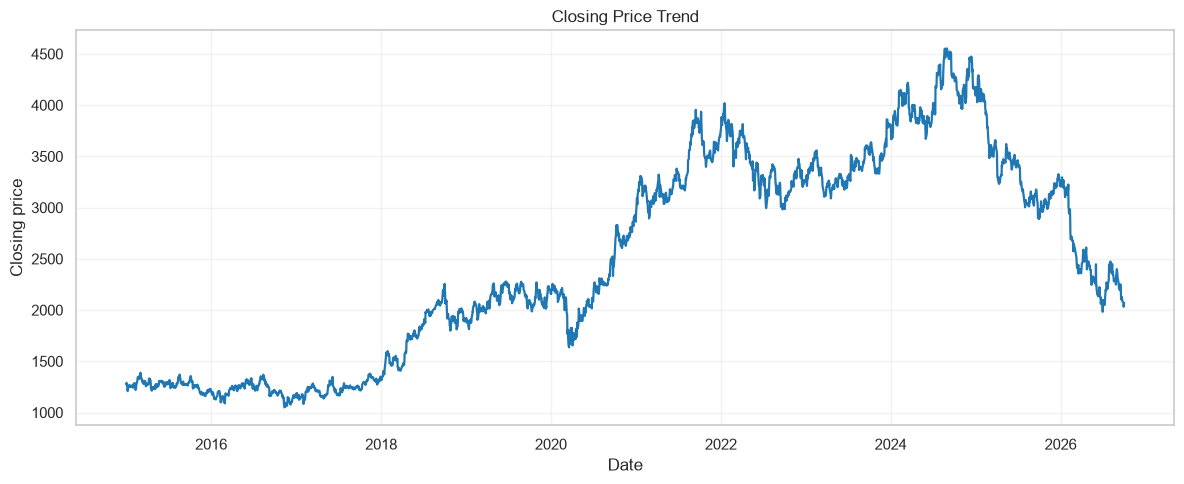

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(selected.index, selected["Close"], color="#1f77b4", linewidth=1.6)
ax.set(title="Closing Price Trend", xlabel="Date", ylabel="Closing price")
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(CHARTS_DIR / "closing_price_trend.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

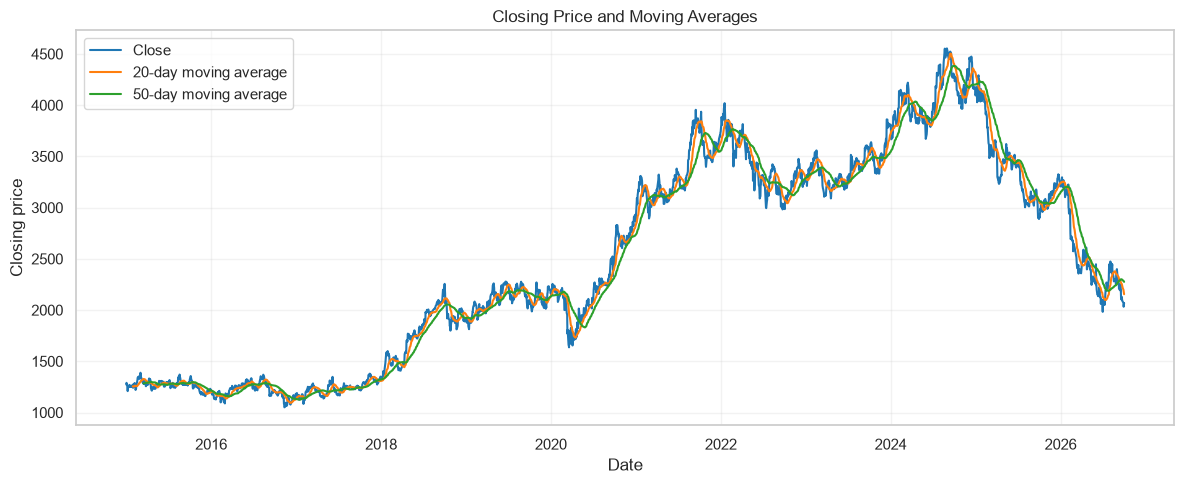

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(selected.index, selected["Close"], label="Close", color="#1f77b4", linewidth=1.5)
ax.plot(selected.index, selected["MA_20"], label="20-day moving average", color="#ff7f0e")
ax.plot(selected.index, selected["MA_50"], label="50-day moving average", color="#2ca02c")
ax.set(title="Closing Price and Moving Averages", xlabel="Date", ylabel="Closing price")
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(CHARTS_DIR / "moving_averages.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

if selected["MA_20"].notna().sum() == 0:
    print("20-day moving average unavailable: fewer than 20 valid closes.")
if selected["MA_50"].notna().sum() == 0:
    print("50-day moving average unavailable: fewer than 50 valid closes.")

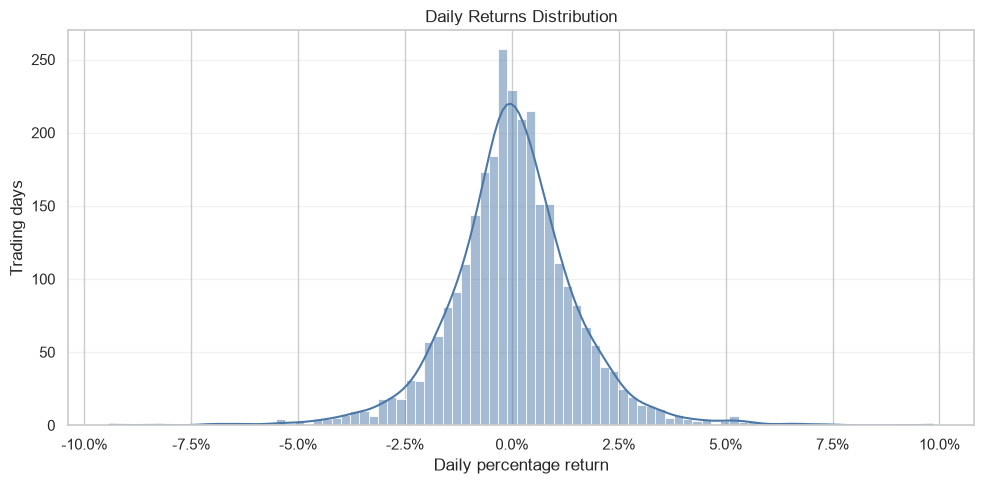

In [6]:
if returns.empty:
    raise ValueError("Daily-return distribution requires at least two valid closes.")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(returns, bins="auto", kde=len(returns) >= 2, ax=ax, color="#4c78a8")
ax.set(title="Daily Returns Distribution", xlabel="Daily percentage return", ylabel="Trading days")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.1%}"))
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(CHARTS_DIR / "daily_returns_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

In [7]:
mean_return = float(returns.mean()) if not returns.empty else np.nan
volatility = float(returns.std(ddof=1)) if len(returns) > 1 else np.nan
minimum_return = float(returns.min()) if not returns.empty else np.nan
maximum_return = float(returns.max()) if not returns.empty else np.nan
cumulative_return = (
    float(selected["Close"].iloc[-1] / selected["Close"].iloc[0] - 1)
    if len(selected) >= 2
    else np.nan
)

metrics = pd.Series(
    {
        "Mean daily return": mean_return,
        "Daily return volatility (sample standard deviation)": volatility,
        "Minimum daily return": minimum_return,
        "Maximum daily return": maximum_return,
        "Cumulative return": cumulative_return,
    },
    name="Selected-period value",
)
display(metrics.to_frame().style.format("{:.2%}", na_rep="N/A"))

def percent_or_na(value: float) -> str:
    return f"{value:.2%}" if np.isfinite(value) else "not available"

interpretation = (
    f"For {selected.index.min():%Y-%m-%d} through {selected.index.max():%Y-%m-%d}, "
    f"the mean daily return was {percent_or_na(mean_return)} and the sample "
    f"standard deviation was {percent_or_na(volatility)}. Daily returns ranged "
    f"from {percent_or_na(minimum_return)} to {percent_or_na(maximum_return)}. "
    f"Cumulative return from the first to last selected close was "
    f"{percent_or_na(cumulative_return)}. These values describe historical "
    "observations only; volatility measures dispersion and does not predict "
    "future performance. This is descriptive analysis, not investment advice."
)
print("## Volatility and Return Interpretation")
print(interpretation)
print(f"Interpretation word count: {len(interpretation.split())}")
assert len(interpretation.split()) <= 200

,Selected-period value
Mean daily return,0.03%
Daily return volatility (sample standard deviation),1.50%
Minimum daily return,-9.41%
Maximum daily return,9.85%
Cumulative return,62.48%


## Volatility and Return Interpretation
For 2015-01-01 through 2026-10-01, the mean daily return was 0.03% and the sample standard deviation was 1.50%. Daily returns ranged from -9.41% to 9.85%. Cumulative return from the first to last selected close was 62.48%. These values describe historical observations only; volatility measures dispersion and does not predict future performance. This is descriptive analysis, not investment advice.
Interpretation word count: 57


In [8]:
first_close = float(selected["Close"].iloc[0])
last_close = float(selected["Close"].iloc[-1])
price_change = last_close / first_close - 1 if first_close else np.nan
print("## Key Findings")
print(
    f"The selected range contains {len(selected):,} trading records from "
    f"{selected.index.min():%Y-%m-%d} to {selected.index.max():%Y-%m-%d}."
)
print(
    f"Closing price changed from {first_close:,.2f} to {last_close:,.2f} "
    f"({percent_or_na(price_change)} close-to-close)."
)
print(
    f"Mean daily return was {percent_or_na(mean_return)}; observed daily "
    f"returns ranged from {percent_or_na(minimum_return)} to "
    f"{percent_or_na(maximum_return)}."
)
print(f"Exported charts: {CHARTS_DIR}")

## Key Findings
The selected range contains 2,906 trading records from 2015-01-01 to 2026-10-01.
Closing price changed from 1,272.78 to 2,068.00 (62.48% close-to-close).
Mean daily return was 0.03%; observed daily returns ranged from -9.41% to 9.85%.
Exported charts: c:\Users\HP\Desktop\DS_3_Stock_Price_Visualization_byte\charts
